# Module 21: Gradient Boosting (Practice Notebook)
## Classification Task with TODO Blocks

In this practice notebook, you will implement **Gradient Boosting for classification** step by step.

### Learning Objectives
- Understand how Gradient Boosting works for classification
- Practice model training, prediction, and evaluation
- Explore the effect of key hyperparameters

**Important:** Complete all TODO blocks. Do not skip steps.


## Step 1: Import Required Libraries

**TODO:** Import NumPy, Pandas, Matplotlib, and required scikit-learn modules.

In [4]:
# TODO: Import necessary libraries
# Hint: numpy, pandas, matplotlib.pyplot
# Hint: load dataset, train_test_split, GradientBoostingClassifier, metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## Step 2: Load Dataset

We will use the **Breast Cancer Wisconsin dataset**, a standard binary classification dataset.

**TODO:** Load the dataset and separate features (X) and target (y).

In [7]:
# TODO: Load the breast cancer dataset
# Hint: sklearn.datasets.load_breast_cancer
# TODO: Assign features to X and labels to y
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target


## Step 3: Inspect the Data

**TODO:** Display the first few rows of X and the distribution of y.

In [13]:
# TODO: View first 5 rows of X
# TODO: Check class distribution in y
X.head()
print("\nClass Distribution in y:")
print(pd.Series(y).value_counts())


Class Distribution in y:
1    357
0    212
Name: count, dtype: int64


## Step 4: Train-Test Split

**TODO:** Split the dataset into training and testing sets.
- Use 80% data for training
- Set random_state for reproducibility

In [14]:
# TODO: Perform train-test split
X_train, X_test , y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state= 42, stratify=y)


## Step 5: Train Gradient Boosting Classifier

**TODO:** Initialize and train a GradientBoostingClassifier.

Suggested starting values:
- n_estimators = 100
- learning_rate = 0.1
- max_depth = 3

In [15]:
# TODO: Initialize GradientBoostingClassifier
# TODO: Fit the model on training data
gb_model = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate= 0.1,
    max_depth= 3,
    random_state= 42
)
gb_model.fit(X_train, y_train)


GradientBoostingClassifier(random_state=42)

## Step 6: Make Predictions

**TODO:** Predict class labels and class probabilities for the test set.

In [16]:
# TODO: Predict class labels
# TODO: Predict class probabilities
y_pred = gb_model.predict(X_test)
y_prob = gb_model.predict_proba(X_test)

print("Predicted Class Labels:")
print(y_pred[:10])
print("\nPredicted Class Probabilities:")
print(y_prob[:5])


Predicted Class Labels:
[0 1 0 0 0 1 1 0 0 0]

Predicted Class Probabilities:
[[9.99667039e-01 3.32960831e-04]
 [1.87393120e-04 9.99812607e-01]
 [9.96776709e-01 3.22329110e-03]
 [8.76223603e-01 1.23776397e-01]
 [9.99562755e-01 4.37245214e-04]]


## Step 7: Model Evaluation

**TODO:** Evaluate the model using:
- Accuracy
- Confusion Matrix
- Classification Report

In [17]:
# TODO: Calculate accuracy score
# TODO: Print confusion matrix
# TODO: Print classification report
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.956140350877193

Confusion Matrix:
[[38  4]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Step 8: Effect of Learning Rate (Experiment)

**TODO:** Train multiple models with different learning rates and compare accuracy.

Suggested learning rates: 0.01, 0.05, 0.1, 0.2

In [19]:
# TODO: Loop over different learning rates
# TODO: Train model and store accuracy for each
# TODO: Display results in a table

learning_rates = [0.01, 0.05, 0.1, 0.2]
lr_results = []

for lr in learning_rates:
  gb_model = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate= lr,
    max_depth= 3,
    random_state= 42
  )
  gb_model.fit(X_train, y_train)
  y_pred = gb_model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  lr_results.append((lr, accuracy))

lr_table = pd.DataFrame({
    "Learning Rate": learning_rates,
    "Accuracy": lr_results
})

print("\nLearning Rate vs Accuracy:")
print(lr_table.sort_values(by="Accuracy", ascending=False))



Learning Rate vs Accuracy:
   Learning Rate                    Accuracy
3           0.20    (0.2, 0.956140350877193)
2           0.10    (0.1, 0.956140350877193)
1           0.05  (0.05, 0.9473684210526315)
0           0.01  (0.01, 0.9210526315789473)


## Step 9: Effect of Tree Depth (Experiment)

**TODO:** Compare model performance for different tree depths.

Suggested depths: 1, 2, 3, 5

In [21]:
depths = [1, 2, 3, 5]
depth_results = []

for depth in depths:
  gb_model = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate= 0.20,
    max_depth= depth,
    random_state= 42
  )
  gb_model.fit(X_train, y_train)
  y_pred = gb_model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  depth_results.append((depth, accuracy))

depth_table = pd.DataFrame(
depth_results,
columns=["max_depth", "Accuracy"]
)

print("\nmax_depth vs Accuracy:")
print(depth_table.sort_values(by="Accuracy", ascending=False))


max_depth vs Accuracy:
   max_depth  Accuracy
0          1  0.964912
2          3  0.956140
3          5  0.956140
1          2  0.947368


## Step 10: Feature Importance

**TODO:** Extract and display the top 10 most important features.


Top 10 Most Important Features:
                 Feature  Importance
20          worst radius    0.622252
27  worst concave points    0.114897
22       worst perimeter    0.077402
21         worst texture    0.048229
11         texture error    0.046054
26       worst concavity    0.014641
28        worst symmetry    0.014360
23            worst area    0.010525
7    mean concave points    0.008368
24      worst smoothness    0.007971


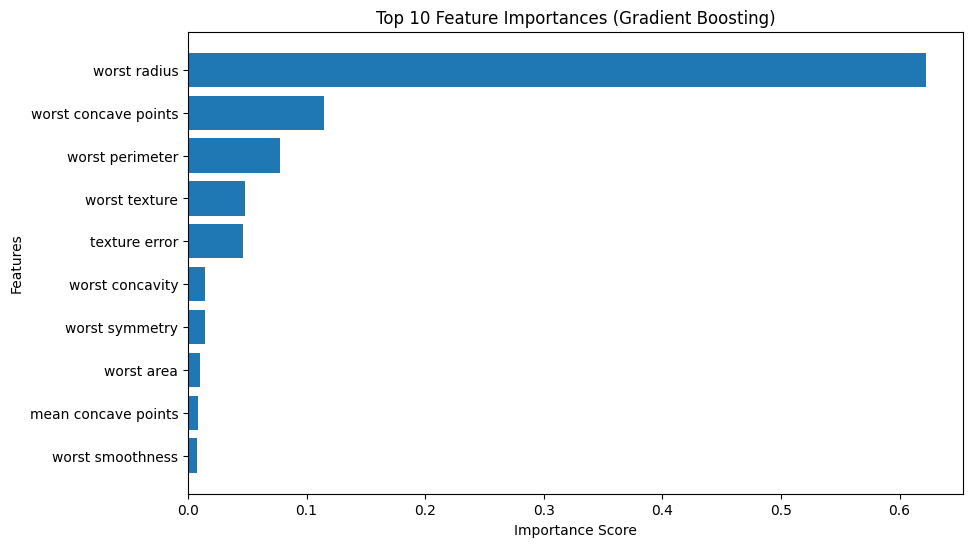

In [22]:
# TODO: Extract feature_importances_
# TODO: Display top 10 features
# TODO: Extract feature_importances_
importances = gb_model.feature_importances_

# Create DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

# TODO: Display top 10 features
top_10_features = feature_importance_df.sort_values(
    by="Importance", ascending=False
).head(10)

print("\nTop 10 Most Important Features:")
print(top_10_features)

# Optional: Plot feature importance
plt.figure(figsize=(10,6))
plt.barh(top_10_features["Feature"], top_10_features["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Feature Importances (Gradient Boosting)")
plt.gca().invert_yaxis()
plt.show()


## Reflection Questions (Answer in Markdown)

1. How does learning rate affect model performance?
2. Why does Gradient Boosting prefer shallow trees?
3. When might Gradient Boosting overfit?
4. Compare this model conceptually with Random Forest.


# **1. How does learning rate affect model performance?**


Lower learning rate makes learning slower but more stable and accurate. Higher learning rate learns faster but may overshoot and reduce accuracy or cause overfitting.


# **2. Why does Gradient Boosting prefer shallow trees?**

Gradient Boosting uses shallow trees (weak learners) to gradually reduce errors step by step, which improves generalization and prevents overfitting.


# **3. When might Gradient Boosting overfit?**

It may overfit when:

n_estimators is too high

max_depth is too large

learning rate is too high

dataset is small or noisy


# **4. Compare this model conceptually with Random Forest.**

Random Forest builds trees independently using bagging, while Gradient Boosting builds trees sequentially where each tree corrects previous errors, making it more accurate but more sensitive to overfitting.